# TW r8fin correlation analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [ ]:
trade = pd.read_parquet('/content/merged_r8fin_trades.parquet')

In [ ]:
ctct = pd.read_csv('ctct.csv')

In [ ]:
ctct.columns

Index(['trade_date', 'executiontime', 'brokerexecutiontime', 'exec_time_et',
       'recapid', 'orderid', 'parentcorrelationorderid', 'executionid', 'firm',
       'client', 'syntheticcontractidentifier', 'instrument',
       'syntheticpricemode', 'syntheticticksize',
       'syntheticcontractdefinition', 'security_type', 'symbol', 'cusip',
       'side', 'quantity', 'price', 'order_source', 'broker_id', 'exchange',
       'exchange_route', 'exchange_endoint', 'exchange_lp', 'is_aggressive',
       'destination', 'order_text', 'quote_or_hedge', 'hedge_target_price',
       'cash_exchange_trade_id', 'timestamp', 'build_id', 'build_name',
       'hide_duration', 'pop_ticks', 'label', 'strategy'],
      dtype='object')

In [ ]:
ctct.instrument.unique()

array(['ct10-ct30 (y)', 'ct5-ct10 (y)', 'ct2-ct5 (y)', 'ct10-ct20 (y)',
       'ct2-ct10 (y)', 'ct2-ct30 (y)', 'ct3-ct10 (y)', 'ct7-ct10 (y)',
       'ct20-ct30 (y)', 'ct5-ct30 (y)', 'ct5-ct7 (y)', 'ct3-ct5 (y)',
       'ct2-ct3 (y)', 'ct7-ct30 (y)', 'ct3-ct7 (y)', 'ct3-ct30 (y)',
       'ct10-ct2 65% (y)', 'ct2-ct7 (y)', 'ct10-ct5 (5y5y) (y)',
       'ust 7_year,ust 10_year', 'ct2-ct20 (y)', 'ct3-ct20 (y)',
       'ct3-ct5 1:1.1', 'factor curve 20 beta', 'ct5-ct10 1x2 dv01 (y)',
       'ct5-ct20 (y)', 'ct5-ct7 106.1% (y)', 'o5-ct30 (y)',
       'factor curve 10 beta (y)', 'ust 30_year,ust 5_year',
       'ust 10_year,ust 5_year', 'ct5-ct10 (y 1/1.14)', 'ct7-ct20 (y)',
       'ct20-ct30 (y) r', 'ust 5_year,ust 30_year',
       'ust 2_year,ust 5_year', 'ct2-ct3 (y) bespoke one off',
       'ct2-ct3 for 925 mfly', 'ct2-ct5 (y) 100/110', 'ct7-ct3 80% (y)',
       'ust 10_year,ust 7_year', 'ust 10_year,ust 30_year',
       'ct3-ct5 (1.15) (y)', 'factor curve 15 beta (y)',
       'ct10-ct2 

In [ ]:
column = [
    'ct10-ct30 (y)', 'ct5-ct10 (y)', 'ct2-ct5 (y)', 'ct10-ct20 (y)',
    'ct7-ct10 (y)', 'ct2-ct3 (y)', 'ct3-ct30 (y)', 'ct5-ct30 (y)',
    'ct2-ct10 (y)', 'ct2-ct30 (y)', 'ct3-ct10 (y)','ct20-ct30 (y)',
    'ct5-ct7 (y)', 'ct3-ct5 (y)','ct7-ct30 (y)', 'ct3-ct7 (y)',
    'ct2-ct7 (y)','ct2-ct20 (y)', 'ct5-ct20 (y)', 'ct7-ct20 (y)'
]

test = ctct[ctct['instrument'].isin(column)]
test


,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,quote_or_hedge,hedge_target_price,cash_exchange_trade_id,timestamp,build_id,build_name,hide_duration,pop_ticks,label,strategy
0,2024-09-16,2024-09-16 07:49:44.736,2024-09-16 07:49:44.734,2024-09-16 03:49:44.734,575336.0,7024427971,7024422997,696326168.0,GVLRYWXG,GLRWVZDL,...,Quote,NaN,1726383418734389|S,1.726473e+18,103383.0,H-MOD,111.0,"comp_0: 0.0, comp_1: 2.0",r8fin_trades,Curve
1,2024-09-16,2024-09-16 07:49:44.740,2024-09-16 07:49:44.738,2024-09-16 03:49:44.738,575336.0,7024427976,7024422997,696326169.0,GVLRYWXG,GLRWVZDL,...,Hedge,101.921875,1726383418734390|B,1.726473e+18,103383.0,H-MOD,111.0,"comp_0: 0.0, comp_1: 2.0",r8fin_trades,Curve
2,2024-09-16,2024-09-16 07:49:44.924,2024-09-16 07:49:44.923,2024-09-16 03:49:44.923,575336.0,7024427983,7024422997,696326170.0,GVLRYWXG,GLRWVZDL,...,Quote,NaN,1726383418734391|S,1.726473e+18,103383.0,H-MOD,111.0,"comp_0: 0.0, comp_1: 2.0",r8fin_trades,Curve
3,2024-09-16,2024-09-16 07:49:44.930,2024-09-16 07:49:44.928,2024-09-16 03:49:44.928,575336.0,7024427988,7024422997,696326171.0,GVLRYWXG,GLRWVZDL,...,Hedge,101.921875,1726383418734392|B,1.726473e+18,103383.0,H-MOD,111.0,"comp_0: 0.0, comp_1: 2.0",r8fin_trades,Curve
4,2024-09-16,2024-09-16 07:49:44.932,2024-09-16 07:49:44.929,2024-09-16 03:49:44.929,575336.0,7024427988,7024422997,696326172.0,GVLRYWXG,GLRWVZDL,...,Hedge,101.921875,O:71139671:19982:193,1.726473e+18,103383.0,H-MOD,111.0,"comp_0: 0.0, comp_1: 2.0",r8fin_trades,Curve
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
633985,2024-10-04,2024-10-04 20:57:55.766,2024-10-04 20:57:55.762,2024-10-04 16:57:55.762,590554.0,7029292255,7028883339,699616780.0,VWOKKTMR,TCGFKGFK,...,Quote,NaN,5629609485429666367,1.728075e+18,78538.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades,Curve
633986,2024-10-04,2024-10-04 20:57:55.770,2024-10-04 20:57:55.767,2024-10-04 16:57:55.767,590554.0,7029292275,7028883339,699616781.0,VWOKKTMR,TCGFKGFK,...,Hedge,100.015625,O:71176201:20000:7555,1.728075e+18,78538.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades,Curve
633987,2024-10-04,2024-10-04 20:58:40.589,2024-10-04 20:58:40.586,2024-10-04 16:58:40.586,590554.0,7029292574,7028883339,699617028.0,VWOKKTMR,TCGFKGFK,...,Quote,NaN,B03278005IZC01,1.728076e+18,78538.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades,Curve
633988,2024-10-04,2024-10-04 20:58:40.599,2024-10-04 20:58:40.597,2024-10-04 16:58:40.597,590554.0,7029292574,7028883339,699617029.0,VWOKKTMR,TCGFKGFK,...,Quote,NaN,5629609485429682236,1.728076e+18,78538.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades,Curve


In [ ]:
col = test.instrument.unique()
col

array(['ct10-ct30 (y)', 'ct5-ct10 (y)', 'ct2-ct5 (y)', 'ct10-ct20 (y)',
       'ct2-ct10 (y)', 'ct2-ct30 (y)', 'ct3-ct10 (y)', 'ct7-ct10 (y)',
       'ct20-ct30 (y)', 'ct5-ct30 (y)', 'ct5-ct7 (y)', 'ct3-ct5 (y)',
       'ct2-ct3 (y)', 'ct7-ct30 (y)', 'ct3-ct7 (y)', 'ct3-ct30 (y)',
       'ct2-ct7 (y)', 'ct2-ct20 (y)', 'ct5-ct20 (y)', 'ct7-ct20 (y)'],
      dtype=object)

In [ ]:
matrix_labels = ['10yr', '20yr', '2yr', '30yr', '3yr', '5yr', '7yr']
cross_impact_matrix = np.array([
    [0.08, 0.01, -0.00, 0.01, 0.01, 0.01, 0.02],
    [0.01, 0.11, -0.00, 0.02, 0.02, 0.06, 0.04],
    [-0.00, -0.00, 0.34, 0.01, -0.00, -0.01, -0.07],
    [0.01, 0.02, 0.01, 0.56, 0.02, 0.04, 0.08],
    [0.01, 0.02, -0.00, 0.02, 0.42, 0.13, 0.04],
    [0.01, 0.06, -0.01, 0.04, 0.13, 12.81, -0.31],
    [0.02, 0.04, -0.07, 0.08, 0.04, -0.31, 3.28]
])
# Mapping instruments to matrix row/column indices
instrument_to_indices = {
    'ct10-ct30 (y)': ('10yr', '30yr'),
    'ct5-ct10 (y)': ('5yr', '10yr'),
    'ct2-ct5 (y)': ('2yr', '5yr'),
    'ct10-ct20 (y)': ('10yr', '20yr'),
    'ct7-ct10 (y)': ('7yr', '10yr'),
    'ct2-ct3 (y)': ('2yr', '3yr'),
    'ct3-ct30 (y)': ('3yr', '30yr'),
    'ct5-ct30 (y)': ('5yr', '30yr'),
    'ct2-ct10 (y)': ('2yr', '10yr'),
    'ct2-ct30 (y)': ('2yr', '30yr'),
    'ct3-ct10 (y)': ('3yr', '10yr'),
    'ct20-ct30 (y)': ('20yr', '30yr'),
    'ct5-ct7 (y)': ('5yr', '7yr'),
    'ct3-ct5 (y)': ('3yr', '5yr'),
    'ct7-ct30 (y)': ('7yr', '30yr'),
    'ct3-ct7 (y)': ('3yr', '7yr'),
    'ct2-ct7 (y)': ('2yr', '7yr'),
    'ct2-ct20 (y)': ('2yr', '20yr'),
    'ct5-ct20 (y)': ('5yr', '20yr'),
    'ct7-ct20 (y)': ('7yr', '20yr')
}

# Convert row/column labels into indices
row_indices = {label: idx for idx, label in enumerate(matrix_labels)}
col_indices = {label: idx for idx, label in enumerate(matrix_labels)}

# Map the impact values based on the instrument column
impact_values = []
for instrument in test['instrument']:
    if instrument in instrument_to_indices:
        row_label, col_label = instrument_to_indices[instrument]
        row_idx = row_indices[row_label]
        col_idx = col_indices[col_label]
        impact_value = cross_impact_matrix[row_idx, col_idx]
        impact_values.append(impact_value)
    else:
        impact_values.append(None)  # Handle cases where instrument is not in the mapping

# Add the impact values as a new column
test['impact_index'] = impact_values

<ipython-input-9-6f652ff28338>:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['impact_index'] = impact_values


In [ ]:
test[['instrument','impact_index']]

,instrument,impact_index
0,ct10-ct30 (y),0.01
1,ct10-ct30 (y),0.01
2,ct10-ct30 (y),0.01
3,ct10-ct30 (y),0.01
4,ct10-ct30 (y),0.01
...,...,...
633985,ct2-ct30 (y),0.01
633986,ct2-ct30 (y),0.01
633987,ct2-ct30 (y),0.01
633988,ct2-ct30 (y),0.01


In [ ]:
test['impact_notional'] = test.quantity * test.impact_index *100

C:\Users\ysnow\AppData\Local\Temp\ipykernel_90212\2036405868.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['impact_notional'] = test.quantity * test.impact_index *100


In [ ]:
test.columns

Index(['trade_date', 'executiontime', 'brokerexecutiontime', 'exec_time_et',
       'recapid', 'orderid', 'parentcorrelationorderid', 'executionid', 'firm',
       'client', 'syntheticcontractidentifier', 'instrument',
       'syntheticpricemode', 'syntheticticksize',
       'syntheticcontractdefinition', 'security_type', 'symbol', 'cusip',
       'side', 'quantity', 'price', 'order_source', 'broker_id', 'exchange',
       'exchange_route', 'exchange_endoint', 'exchange_lp', 'is_aggressive',
       'destination', 'order_text', 'quote_or_hedge', 'hedge_target_price',
       'cash_exchange_trade_id', 'timestamp', 'build_id', 'build_name',
       'hide_duration', 'pop_ticks', 'label', 'strategy', 'impact_index',
       'impact_notional'],
      dtype='object')

In [ ]:
test.hedge_target_price

0                NaN
1         101.921875
2                NaN
3         101.921875
4         101.921875
             ...    
633985           NaN
633986    100.015625
633987           NaN
633988           NaN
633989           NaN
Name: hedge_target_price, Length: 606162, dtype: float64

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Define input features and target column
reg_col = ['firm', 'client', 'is_aggressive', 'quote_or_hedge', 'hedge_target_price','recapid']
target_col = 'impact_notional'

# Split the data into features (X) and target (y)
X = test[reg_col]
y = test[target_col]

# Encode categorical variables
categorical_features = ['firm', 'client', 'quote_or_hedge','is_aggressive','recapid']
label_encoders = {}

for col in categorical_features:
    label_encoders[col] = LabelEncoder()
    X[col] = label_encoders[col].fit_transform(X[col])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define and train the Random Forest Regressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
score = model.score(X_test, y_test)
print(f"Model R^2 Score: {score:.4f}")

C:\Users\ysnow\AppData\Local\Temp\ipykernel_90212\3227794104.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = label_encoders[col].fit_transform(X[col])
C:\Users\ysnow\AppData\Local\Temp\ipykernel_90212\3227794104.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = label_encoders[col].fit_transform(X[col])
C:\Users\ysnow\AppData\Local\Temp\ipykernel_90212\3227794104.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

Model R^2 Score: 0.8469


              Feature  Importance
5             recapid    0.534081
1              client    0.193154
4  hedge_target_price    0.159170
0                firm    0.095065
2       is_aggressive    0.016684
3      quote_or_hedge    0.001846


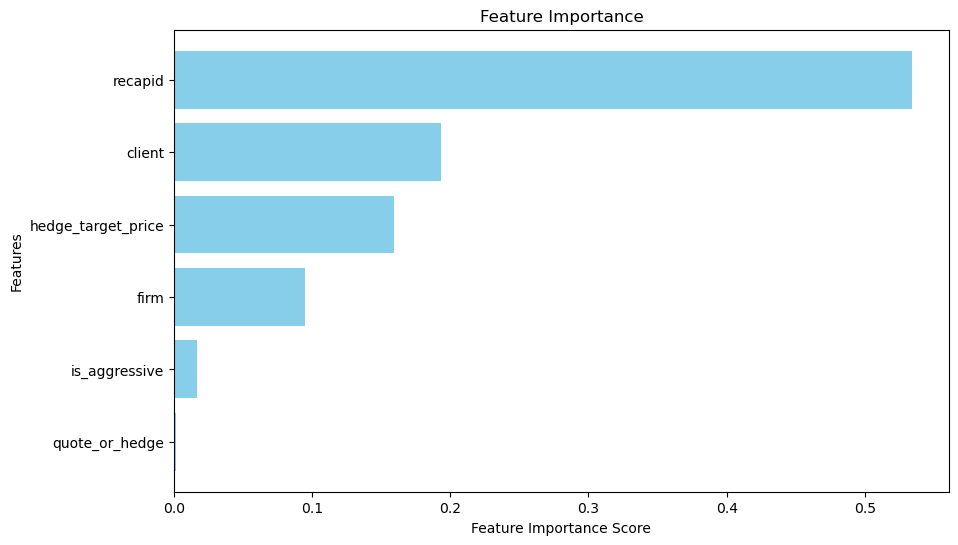

In [ ]:
# Extract feature importances
feature_importances = model.feature_importances_

# Combine feature names with their importances
feature_importance_df = pd.DataFrame({'Feature': reg_col, 'Importance': feature_importances})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importance dataframe
print(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.gca().invert_yaxis()  # Reverse order for better readability
plt.show()

# cumulative impact

In [ ]:
test.columns

Index(['trade_date', 'executiontime', 'brokerexecutiontime', 'exec_time_et',
       'recapid', 'orderid', 'parentcorrelationorderid', 'executionid', 'firm',
       'client', 'syntheticcontractidentifier', 'instrument',
       'syntheticpricemode', 'syntheticticksize',
       'syntheticcontractdefinition', 'security_type', 'symbol', 'cusip',
       'side', 'quantity', 'price', 'order_source', 'broker_id', 'exchange',
       'exchange_route', 'exchange_endoint', 'exchange_lp', 'is_aggressive',
       'destination', 'order_text', 'quote_or_hedge', 'hedge_target_price',
       'cash_exchange_trade_id', 'timestamp', 'build_id', 'build_name',
       'hide_duration', 'pop_ticks', 'label', 'strategy'],
      dtype='object')

In [ ]:
test

,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,quote_or_hedge,hedge_target_price,cash_exchange_trade_id,timestamp,build_id,build_name,hide_duration,pop_ticks,label,strategy
0,2024-09-16,2024-09-16 07:49:44.736,2024-09-16 07:49:44.734,2024-09-16 03:49:44.734,575336.0,7024427971,7024422997,696326168.0,GVLRYWXG,GLRWVZDL,...,Quote,NaN,1726383418734389|S,1.726473e+18,103383.0,H-MOD,111.0,"comp_0: 0.0, comp_1: 2.0",r8fin_trades,Curve
1,2024-09-16,2024-09-16 07:49:44.740,2024-09-16 07:49:44.738,2024-09-16 03:49:44.738,575336.0,7024427976,7024422997,696326169.0,GVLRYWXG,GLRWVZDL,...,Hedge,101.921875,1726383418734390|B,1.726473e+18,103383.0,H-MOD,111.0,"comp_0: 0.0, comp_1: 2.0",r8fin_trades,Curve
2,2024-09-16,2024-09-16 07:49:44.924,2024-09-16 07:49:44.923,2024-09-16 03:49:44.923,575336.0,7024427983,7024422997,696326170.0,GVLRYWXG,GLRWVZDL,...,Quote,NaN,1726383418734391|S,1.726473e+18,103383.0,H-MOD,111.0,"comp_0: 0.0, comp_1: 2.0",r8fin_trades,Curve
3,2024-09-16,2024-09-16 07:49:44.930,2024-09-16 07:49:44.928,2024-09-16 03:49:44.928,575336.0,7024427988,7024422997,696326171.0,GVLRYWXG,GLRWVZDL,...,Hedge,101.921875,1726383418734392|B,1.726473e+18,103383.0,H-MOD,111.0,"comp_0: 0.0, comp_1: 2.0",r8fin_trades,Curve
4,2024-09-16,2024-09-16 07:49:44.932,2024-09-16 07:49:44.929,2024-09-16 03:49:44.929,575336.0,7024427988,7024422997,696326172.0,GVLRYWXG,GLRWVZDL,...,Hedge,101.921875,O:71139671:19982:193,1.726473e+18,103383.0,H-MOD,111.0,"comp_0: 0.0, comp_1: 2.0",r8fin_trades,Curve
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
633985,2024-10-04,2024-10-04 20:57:55.766,2024-10-04 20:57:55.762,2024-10-04 16:57:55.762,590554.0,7029292255,7028883339,699616780.0,VWOKKTMR,TCGFKGFK,...,Quote,NaN,5629609485429666367,1.728075e+18,78538.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades,Curve
633986,2024-10-04,2024-10-04 20:57:55.770,2024-10-04 20:57:55.767,2024-10-04 16:57:55.767,590554.0,7029292275,7028883339,699616781.0,VWOKKTMR,TCGFKGFK,...,Hedge,100.015625,O:71176201:20000:7555,1.728075e+18,78538.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades,Curve
633987,2024-10-04,2024-10-04 20:58:40.589,2024-10-04 20:58:40.586,2024-10-04 16:58:40.586,590554.0,7029292574,7028883339,699617028.0,VWOKKTMR,TCGFKGFK,...,Quote,NaN,B03278005IZC01,1.728076e+18,78538.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades,Curve
633988,2024-10-04,2024-10-04 20:58:40.599,2024-10-04 20:58:40.597,2024-10-04 16:58:40.597,590554.0,7029292574,7028883339,699617029.0,VWOKKTMR,TCGFKGFK,...,Quote,NaN,5629609485429682236,1.728076e+18,78538.0,H-MOD,0.0,"comp_0: 1.0, comp_1: 0.0",r8fin_trades,Curve


In [ ]:
test['instrument'].unique()

array(['ct10-ct30 (y)', 'ct5-ct10 (y)', 'ct2-ct5 (y)', 'ct10-ct20 (y)',
       'ct2-ct10 (y)', 'ct2-ct30 (y)', 'ct3-ct10 (y)', 'ct7-ct10 (y)',
       'ct20-ct30 (y)', 'ct5-ct30 (y)', 'ct5-ct7 (y)', 'ct3-ct5 (y)',
       'ct2-ct3 (y)', 'ct7-ct30 (y)', 'ct3-ct7 (y)', 'ct3-ct30 (y)',
       'ct2-ct7 (y)', 'ct2-ct20 (y)', 'ct5-ct20 (y)', 'ct7-ct20 (y)'],
      dtype=object)

In [ ]:
test['symbol'].unique()

array(['30 Year', '10 Year', '5 Year', '2 Year', '20 Year', '3 Year',
       '7 Year'], dtype=object)

<ipython-input-22-98d0ace64b51>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_data['executiontime'] = pd.to_datetime(real_data['executiontime'])
<ipython-input-22-98d0ace64b51>:29: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_data = real_data[real_data['symbol'].str.contains('|'.join(symbols))]


Empty DataFrame
Columns: []
Index: []


In [ ]:
import pandas as pd
import numpy as np

# Example function modified for actual data
def calculate_cumulative_impact_with_decay(real_data, matrix, bin_size=10, decay_rate=0.1, specific_instrument=None):
    """
    Calculate the cumulative impact of trades using the cross-impact matrix
    with an exponential decay factor, focusing only on trades involving a specific instrument and its symbols.

    Parameters:
    real_data (pd.DataFrame): DataFrame containing trades with columns ['trade_date', 'executiontime', 'instrument', 'symbol', 'quantity'].
                              'executiontime' should be a datetime, 'instrument' is the bond type (e.g., CT5, CT10).
    matrix (pd.DataFrame): Cross-impact matrix (rows and columns as instruments).
    bin_size (int): Rolling time window in seconds (default is 10).
    decay_rate (float): Decay rate (lambda) for the exponential decay (default is 0.1).
    specific_instrument (str): The instrument to focus on (e.g., 'ct5-ct10 (y)').

    Returns:
    pd.DataFrame: DataFrame with cumulative impacts for the first three trades.
    """
    # Ensure 'executiontime' is datetime
    real_data.loc[:, 'executiontime'] = pd.to_datetime(real_data['executiontime'])
    real_data = real_data.sort_values(['executiontime']).reset_index(drop=True)

    # Map symbols to match those in the cross-impact matrix
    symbol_mapping = {
        '5 Year': '5yr',
        '10 Year': '10yr',
        '2 Year': '2yr',
        '3 Year': '3yr',
        '7 Year': '7yr',
        '30 Year': '30yr'
    }
    real_data['symbol_mapped'] = real_data['symbol'].map(symbol_mapping)

    # Filter trades based on the specific instrument
    if specific_instrument:
        # Step 1: Filter trades matching the specific instrument
        instrument_trades = real_data[real_data['instrument'] == specific_instrument]

        # Step 2: Identify unique mapped symbols from these trades
        symbols = instrument_trades['symbol_mapped'].unique()

        # Step 3: Filter all trades that have these mapped symbols
        filtered_data = real_data[real_data['symbol_mapped'].isin(symbols)]
    else:
        filtered_data = real_data

    # Initialize results
    cumulative_impacts = []

    # Iterate through trades
    for idx, trade in filtered_data.iterrows():
        trade_time = trade['executiontime']
        trade_symbol = trade['symbol_mapped']
        trade_volume = trade['quantity']

        # Define the rolling window
        window_start = trade_time
        window_end = trade_time + pd.Timedelta(seconds=bin_size)

        # Filter trades within the rolling window
        window_trades = filtered_data[(filtered_data['executiontime'] > window_start) & (filtered_data['executiontime'] <= window_end)]

        for _, next_trade in window_trades.iterrows():
            next_symbol = next_trade['symbol_mapped']
            next_volume = next_trade['quantity']
            next_trade_time = next_trade['executiontime']

            # Calculate time difference
            delta_t = (next_trade_time - trade_time).total_seconds()

            # Apply decay factor
            decay_factor = np.exp(-decay_rate * delta_t)

            # Get impact from the matrix
            if trade_symbol in matrix.index and next_symbol in matrix.columns:
                impact = matrix.loc[trade_symbol, next_symbol]
            else:
                impact = 0

            # Calculate weighted impact
            weighted_impact = impact * trade_volume * decay_factor

            # Append result
            cumulative_impacts.append({
                'time': trade_time,
                'instrument': specific_instrument,
                'from_instrument': trade_symbol,
                'to_instrument': next_symbol,
                'decay_factor': decay_factor,
                'weighted_impact': weighted_impact,
                'next_trade_time': next_trade_time
            })

        # Limit to first three trades for the result
        if len(cumulative_impacts) >= 10:
            break

    # Convert results to DataFrame
    impact_df = pd.DataFrame(cumulative_impacts[:10])

    return impact_df

# Use the actual test dataset
real_data = test

# Construct the cross-impact matrix from image 2 data
cross_impact_matrix = pd.DataFrame(
    data=[
        [0.08, 0.01, -0.00, 0.01, 0.01, 0.01],
        [0.01, 0.11, -0.00, 0.02, 0.02, 0.06],
        [-0.00, -0.00, 0.34, -0.01, -0.00, -0.07],
        [0.01, 0.02, -0.01, 0.56, 0.02, 0.04],
        [0.01, 0.02, -0.00, 0.02, 0.42, 0.13],
        [0.02, 0.06, -0.07, 0.04, 0.13, 3.28]
    ],
    index=['2yr', '3yr', '5yr', '7yr', '10yr', '30yr'],
    columns=['2yr', '3yr', '5yr', '7yr', '10yr', '30yr']
)

# Run the cumulative impact calculation with decay for a specific instrument
specific_instrument = "ct5-ct10 (y)"
impact_results = calculate_cumulative_impact_with_decay(real_data, cross_impact_matrix, bin_size=10, decay_rate=0.1, specific_instrument=specific_instrument)

# Display results
print(impact_results)

                     time    instrument from_instrument to_instrument  \
0 2024-08-04 23:51:26.441  ct5-ct10 (y)             5yr           5yr   
1 2024-08-04 23:53:08.185  ct5-ct10 (y)             5yr           5yr   
2 2024-08-04 23:53:08.185  ct5-ct10 (y)             5yr           5yr   
3 2024-08-04 23:53:08.196  ct5-ct10 (y)             5yr           5yr   
4 2024-08-04 23:53:10.932  ct5-ct10 (y)             5yr           5yr   
5 2024-08-04 23:53:10.932  ct5-ct10 (y)             5yr           5yr   
6 2024-08-04 23:53:19.219  ct5-ct10 (y)             5yr           5yr   
7 2024-08-04 23:53:19.219  ct5-ct10 (y)             5yr           5yr   
8 2024-08-04 23:53:20.433  ct5-ct10 (y)             5yr           5yr   
9 2024-08-05 00:17:19.644  ct5-ct10 (y)             5yr           5yr   

   decay_factor  weighted_impact         next_trade_time  
0      0.937724         0.318826 2024-08-04 23:51:27.084  
1      0.998901         0.339626 2024-08-04 23:53:08.196  
2      0.759800    

In [ ]:
impact_results

,time,instrument,from_instrument,to_instrument,decay_factor,weighted_impact,next_trade_time
0,2024-08-04 23:51:26.441,ct5-ct10 (y),5yr,5yr,0.937724,0.318826,2024-08-04 23:51:27.084
1,2024-08-04 23:53:08.185,ct5-ct10 (y),5yr,5yr,0.998901,0.339626,2024-08-04 23:53:08.196
2,2024-08-04 23:53:08.185,ct5-ct10 (y),5yr,5yr,0.759800,0.258332,2024-08-04 23:53:10.932
3,2024-08-04 23:53:08.196,ct5-ct10 (y),5yr,5yr,0.760636,0.258616,2024-08-04 23:53:10.932
4,2024-08-04 23:53:10.932,ct5-ct10 (y),5yr,5yr,0.436617,0.148450,2024-08-04 23:53:19.219
5,2024-08-04 23:53:10.932,ct5-ct10 (y),5yr,5yr,0.386702,0.131479,2024-08-04 23:53:20.433
6,2024-08-04 23:53:19.219,ct5-ct10 (y),5yr,5yr,0.885680,0.301131,2024-08-04 23:53:20.433
7,2024-08-04 23:53:19.219,ct5-ct10 (y),5yr,5yr,0.800115,0.272039,2024-08-04 23:53:21.449
8,2024-08-04 23:53:20.433,ct5-ct10 (y),5yr,5yr,0.903391,0.307153,2024-08-04 23:53:21.449
9,2024-08-05 00:17:19.644,ct5-ct10 (y),5yr,5yr,0.998002,0.339321,2024-08-05 00:17:19.664


In [ ]:
import pandas as pd
import numpy as np

# Example function modified for actual data
def calculate_cumulative_impact_with_decay(real_data, matrix, bin_size=10, decay_rate=0.1, specific_instrument=None):
    """
    Calculate the cumulative impact of trades using the cross-impact matrix
    with an exponential decay factor, focusing only on trades involving a specific instrument and its symbols.

    Parameters:
    real_data (pd.DataFrame): DataFrame containing trades with columns ['trade_date', 'executiontime', 'instrument', 'symbol', 'quantity'].
                              'executiontime' should be a datetime, 'instrument' is the bond type (e.g., CT5, CT10).
    matrix (pd.DataFrame): Cross-impact matrix (rows and columns as instruments).
    bin_size (int): Rolling time window in seconds (default is 10).
    decay_rate (float): Decay rate (lambda) for the exponential decay (default is 0.1).
    specific_instrument (str): The instrument to focus on (e.g., 'ct5-ct10 (y)').

    Returns:
    pd.DataFrame: DataFrame with cumulative impacts for all fills.
    """
    # Ensure 'executiontime' is datetime
    real_data.loc[:, 'executiontime'] = pd.to_datetime(real_data['executiontime'])
    real_data = real_data.sort_values(['executiontime']).reset_index(drop=True)

    # Map symbols to match those in the cross-impact matrix
    symbol_mapping = {
        '5 Year': '5yr',
        '10 Year': '10yr',
        '2 Year': '2yr',
        '3 Year': '3yr',
        '7 Year': '7yr',
        '30 Year': '30yr'
    }
    real_data['symbol_mapped'] = real_data['symbol'].map(symbol_mapping)

    # Filter trades based on the specific instrument
    if specific_instrument:
        # Step 1: Filter trades matching the specific instrument
        instrument_trades = real_data[real_data['instrument'] == specific_instrument]

        # Step 2: Identify unique mapped symbols from these trades
        symbols = instrument_trades['symbol_mapped'].unique()

        # Step 3: Filter all trades that have these mapped symbols
        filtered_data = real_data[real_data['symbol_mapped'].isin(symbols)]
    else:
        filtered_data = real_data

    # Initialize results
    cumulative_impacts = []

    # Iterate through trades
    for idx, trade in filtered_data.iterrows():
        trade_time = trade['executiontime']
        trade_symbol = trade['symbol_mapped']
        trade_volume = trade['quantity']

        # Define the rolling window
        window_start = trade_time
        window_end = trade_time + pd.Timedelta(seconds=bin_size)

        # Filter trades within the rolling window
        window_trades = filtered_data[(filtered_data['executiontime'] > window_start) & (filtered_data['executiontime'] <= window_end)]

        for _, next_trade in window_trades.iterrows():
            next_symbol = next_trade['symbol_mapped']
            next_volume = next_trade['quantity']
            next_trade_time = next_trade['executiontime']

            # Calculate time difference
            delta_t = (next_trade_time - trade_time).total_seconds()

            # Apply decay factor
            decay_factor = np.exp(-decay_rate * delta_t)

            # Get impact from the matrix
            if trade_symbol in matrix.index and next_symbol in matrix.columns:
                impact = matrix.loc[trade_symbol, next_symbol]
            else:
                impact = 0

            # Calculate weighted impact
            weighted_impact = impact * trade_volume * decay_factor

            # Append result
            cumulative_impacts.append({
                'time': trade_time,
                'from_instrument': trade_symbol,
                'to_instrument': next_symbol,
                'impact': impact,
                'decay_factor': decay_factor,
                'weighted_impact': weighted_impact,
                'next_trade_time': next_trade_time
            })

    # Convert results to DataFrame
    impact_df = pd.DataFrame(cumulative_impacts)

    return impact_df

# Use the actual test dataset
real_data = test

# Construct the cross-impact matrix from image 2 data
cross_impact_matrix = pd.DataFrame(
    data=[
        [0.08, 0.01, -0.00, 0.01, 0.01, 0.01],
        [0.01, 0.11, -0.00, 0.02, 0.02, 0.06],
        [-0.00, -0.00, 0.34, -0.01, -0.00, -0.07],
        [0.01, 0.02, -0.01, 0.56, 0.02, 0.04],
        [0.01, 0.02, -0.00, 0.02, 0.42, 0.13],
        [0.02, 0.06, -0.07, 0.04, 0.13, 3.28]
    ],
    index=['2yr', '3yr', '5yr', '7yr', '10yr', '30yr'],
    columns=['2yr', '3yr', '5yr', '7yr', '10yr', '30yr']
)

# Run the cumulative impact calculation with decay for a specific instrument
specific_instrument = "ct7-ct20 (y)"
impact_results = calculate_cumulative_impact_with_decay(real_data, cross_impact_matrix, bin_size=10, decay_rate=0.1, specific_instrument=specific_instrument)

# Display results
print(impact_results)

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np

# Optimized function for large datasets

def calculate_cumulative_impact_with_decay(real_data, matrix, bin_size=10, decay_rate=0.1, specific_instrument=None):
    """
    Calculate the cumulative impact of trades using the cross-impact matrix
    with an exponential decay factor, focusing only on trades involving a specific instrument and its symbols.

    Parameters:
    real_data (pd.DataFrame): DataFrame containing trades with columns ['trade_date', 'executiontime', 'instrument', 'symbol', 'quantity'].
                              'executiontime' should be a datetime, 'instrument' is the bond type (e.g., CT5, CT10).
    matrix (pd.DataFrame): Cross-impact matrix (rows and columns as instruments).
    bin_size (int): Rolling time window in seconds (default is 10).
    decay_rate (float): Decay rate (lambda) for the exponential decay (default is 0.1).
    specific_instrument (str): The instrument to focus on (e.g., 'ct5-ct10 (y)').

    Returns:
    pd.DataFrame: DataFrame with cumulative impacts for all fills.
    """
    # Ensure 'executiontime' is datetime
    real_data['executiontime'] = pd.to_datetime(real_data['executiontime'])
    real_data = real_data.sort_values(['executiontime']).reset_index(drop=True)

    # Map symbols to match those in the cross-impact matrix
    symbol_mapping = {
        '5 Year': '5yr',
        '10 Year': '10yr',
        '2 Year': '2yr',
        '3 Year': '3yr',
        '7 Year': '7yr',
        '30 Year': '30yr'
    }
    real_data['symbol_mapped'] = real_data['symbol'].map(symbol_mapping)

    # Filter trades based on the specific instrument
    if specific_instrument:
        instrument_trades = real_data[real_data['instrument'] == specific_instrument]
        symbols = instrument_trades['symbol_mapped'].unique()
        filtered_data = real_data[real_data['symbol_mapped'].isin(symbols)]
    else:
        filtered_data = real_data

    # Initialize results
    cumulative_impacts = []

    # Iterate through trades
    for idx, trade in filtered_data.iterrows():
        trade_time = trade['executiontime']
        trade_symbol = trade['symbol_mapped']
        trade_volume = trade['quantity']  # Quantity is in million $

        # Filter trades within the rolling window
        window_trades = filtered_data[
            (filtered_data['executiontime'] > trade_time)
            & (filtered_data['executiontime'] <= trade_time + pd.Timedelta(seconds=bin_size))
        ]

        # Calculate impacts for all trades in the window
        for _, next_trade in window_trades.iterrows():
            next_symbol = next_trade['symbol_mapped']
            next_volume = next_trade['quantity']  # Quantity is in million $
            delta_t = (next_trade['executiontime'] - trade_time).total_seconds()

            # Apply decay factor
            decay_factor = np.exp(-decay_rate * delta_t)

            # Get impact from the matrix
            impact = (
                matrix.loc[trade_symbol, next_symbol]
                if trade_symbol in matrix.index and next_symbol in matrix.columns
                else 0
            )

            # Calculate weighted impact
            weighted_impact = impact * trade_volume * decay_factor

            # Append result
            cumulative_impacts.append(
                {
                    'time': trade['executiontime'],
                    'from_instrument': trade_symbol,
                    'to_instrument': next_symbol,
                    'impact': impact,
                    'decay_factor': decay_factor,
                    'weighted_impact': weighted_impact,
                    'next_trade_time': next_trade['executiontime'],
                }
            )

    # Convert results to DataFrame
    impact_df = pd.DataFrame(cumulative_impacts)

    return impact_df

def generate_summary_table(real_data, matrix, instruments):
    """
    Generate a summary table for the specified instruments.

    Parameters:
    real_data (pd.DataFrame): Trade data.
    matrix (pd.DataFrame): Cross-impact matrix.
    instruments (list): List of instruments to summarize.

    Returns:
    pd.DataFrame: Summary table with calculated metrics.
    """
    summary = []

    for instrument in instruments:
        # Calculate cumulative impacts
        impact_results = calculate_cumulative_impact_with_decay(
            real_data, matrix, specific_instrument=instrument
        )

        # Calculate summary metrics
        notional_value = real_data[real_data['instrument'] == instrument][
            'quantity'
        ].sum()  # Sum of quantity in million $
        num_trades = real_data[real_data['instrument'] == instrument].shape[0]

        # Get the first three impacts (in basis points)
        if not impact_results.empty:
            first_three_impacts = impact_results['weighted_impact'].head(3).tolist()
        else:
            first_three_impacts = [0, 0, 0]

        while len(first_three_impacts) < 3:
            first_three_impacts.append(0)  # Fill with zeros if fewer than 3 impacts

        total_cross_impact = (
            impact_results['weighted_impact'].sum()
            if not impact_results.empty
            else 0
        )

        # Append row to summary
        summary.append(
            {
                'Instrument': instrument,
                'Notional Value (Mil. $)': notional_value,
                'Number of Trades': num_trades,
                'Price Impact Fill 1 (bps)': first_three_impacts[0],
                'Price Impact Fill 2 (bps)': first_three_impacts[1],
                'Price Impact Fill 3 (bps)': first_three_impacts[2],
                'Total Cross Impact (bps)': total_cross_impact,
                'Total Savings ($)': 0,  # Placeholder for Total Savings
            }
        )

    return pd.DataFrame(summary)

# Use the actual test dataset
real_data = test.copy()

# Construct the cross-impact matrix from image 2 data
cross_impact_matrix = pd.DataFrame(
    data=[
        [0.08, 0.01, -0.00, 0.01, 0.01, 0.01],
        [0.01, 0.11, -0.00, 0.02, 0.02, 0.06],
        [-0.00, -0.00, 0.34, -0.01, -0.00, -0.07],
        [0.01, 0.02, -0.01, 0.56, 0.02, 0.04],
        [0.01, 0.02, -0.00, 0.02, 0.42, 0.13],
        [0.02, 0.06, -0.07, 0.04, 0.13, 3.28],
    ],
    index=['2yr', '3yr', '5yr', '7yr', '10yr', '30yr'],
    columns=['2yr', '3yr', '5yr', '7yr', '10yr', '30yr'],
)

# List of instruments to summarize
instruments = [
    'ct10-ct30 (y)', 'ct5-ct10 (y)', 'ct2-ct5 (y)', 'ct10-ct20 (y)',
       'ct2-ct10 (y)', 'ct2-ct30 (y)', 'ct3-ct10 (y)', 'ct7-ct10 (y)',
       'ct20-ct30 (y)', 'ct5-ct30 (y)', 'ct5-ct7 (y)', 'ct3-ct5 (y)',
       'ct2-ct3 (y)', 'ct7-ct30 (y)', 'ct3-ct7 (y)', 'ct3-ct30 (y)',
       'ct2-ct7 (y)', 'ct2-ct20 (y)', 'ct5-ct20 (y)', 'ct7-ct20 (y)'
]

# Generate the summary table
summary_table = generate_summary_table(real_data, cross_impact_matrix, instruments)

# Display the summary table
print(summary_table)

      Instrument  Notional Value (Mil. $)  Number of Trades  \
0  ct10-ct30 (y)                 102556.0             77136   
1   ct5-ct10 (y)                 181261.0            135866   
2    ct2-ct5 (y)                  36478.0             23825   
3  ct10-ct20 (y)                   8063.0              6654   
4   ct2-ct10 (y)                  62011.0             34434   
5   ct5-ct30 (y)                 139206.0             84527   
6   ct3-ct10 (y)                  23804.0             16321   
7  ct20-ct30 (y)                  24568.0             23264   
8    ct3-ct7 (y)                   9583.0              6736   

   Price Impact Fill 1 (bps)  Price Impact Fill 2 (bps)  \
0                   3.086517                   3.056417   
1                   0.318826                   0.339626   
2                   0.318826                   0.339626   
3                   0.838825                   0.837819   
4                   0.079984                   0.049990   
5              

In [ ]:
summary_table

,Instrument,Notional Value (Mil. $),Number of Trades,Price Impact Fill 1 (bps),Price Impact Fill 2 (bps),Price Impact Fill 3 (bps),Total Cross Impact (bps),Total Savings ($)
0,ct10-ct30 (y),102556.0,77136,3.086517,3.056417,2.999194,1.419401e+06,0
1,ct5-ct10 (y),181261.0,135866,0.318826,0.339626,0.258332,1.465909e+06,0
2,ct2-ct5 (y),36478.0,23825,0.318826,0.339626,0.258332,1.015003e+06,0
3,ct10-ct20 (y),8063.0,6654,0.838825,0.837819,0.836981,4.449316e+05,0
4,ct2-ct10 (y),62011.0,34434,0.079984,0.049990,0.399600,5.711434e+05,0
5,ct5-ct30 (y),139206.0,84527,0.318826,0.339626,0.258332,1.738590e+06,0
6,ct3-ct10 (y),23804.0,16321,0.082153,0.079645,0.077191,5.544112e+05,0
7,ct20-ct30 (y),24568.0,23264,3.086517,3.056417,2.999194,9.094151e+05,0
8,ct3-ct7 (y),9583.0,6736,0.082153,0.079645,0.077191,3.049816e+05,0


In [ ]:
import pandas as pd
import numpy as np

# Optimized function for large datasets

def calculate_cumulative_impact_with_decay(real_data, matrix, bin_size=10, decay_rate=0.1, specific_instrument=None):

    # Ensure 'executiontime' is datetime
    real_data['executiontime'] = pd.to_datetime(real_data['executiontime'])
    real_data = real_data.sort_values(['executiontime']).reset_index(drop=True)

    # Map symbols to match those in the cross-impact matrix
    symbol_mapping = {
        '5 Year': '5yr',
        '10 Year': '10yr',
        '2 Year': '2yr',
        '3 Year': '3yr',
        '7 Year': '7yr',
        '30 Year': '30yr'
    }
    real_data['symbol_mapped'] = real_data['symbol'].map(symbol_mapping)

    # Filter trades based on the specific instrument
    if specific_instrument:
        instrument_trades = real_data[real_data['instrument'] == specific_instrument]
        symbols = instrument_trades['symbol_mapped'].unique()
        filtered_data = real_data[real_data['symbol_mapped'].isin(symbols)]
    else:
        filtered_data = real_data

    # Initialize results
    cumulative_impacts = []

    # Iterate through trades
    for idx, trade in filtered_data.iterrows():
        trade_time = trade['executiontime']
        trade_symbol = trade['symbol_mapped']
        trade_volume = trade['quantity']  # Quantity is in million $

        # Filter trades within the rolling window
        window_trades = filtered_data[
            (filtered_data['executiontime'] > trade_time)
            & (filtered_data['executiontime'] <= trade_time + pd.Timedelta(seconds=bin_size))
        ]

        # Calculate impacts for all trades in the window
        for _, next_trade in window_trades.iterrows():
            next_symbol = next_trade['symbol_mapped']
            next_volume = next_trade['quantity']  # Quantity is in million $
            delta_t = (next_trade['executiontime'] - trade_time).total_seconds()

            # Apply decay factor
            decay_factor = np.exp(-decay_rate * delta_t)

            # Get impact from the matrix
            impact = (
                matrix.loc[trade_symbol, next_symbol]
                if trade_symbol in matrix.index and next_symbol in matrix.columns
                else 0
            )

            # Calculate weighted impact
            weighted_impact = impact * trade_volume * decay_factor

            # Append result
            cumulative_impacts.append(
                {
                    'time': trade['executiontime'],
                    'from_instrument': trade_symbol,
                    'to_instrument': next_symbol,
                    'impact': impact,
                    'decay_factor': decay_factor,
                    'weighted_impact': weighted_impact,
                    'next_trade_time': next_trade['executiontime'],
                }
            )

    # Convert results to DataFrame
    impact_df = pd.DataFrame(cumulative_impacts)

    return impact_df

def generate_summary_table(real_data, matrix, instruments):

    summary = []

    for instrument in instruments:
        # Calculate cumulative impacts
        impact_results = calculate_cumulative_impact_with_decay(
            real_data, matrix, specific_instrument=instrument
        )

        # Calculate summary metrics
        notional_value = real_data[real_data['instrument'] == instrument][
            'quantity'
        ].sum()  # Sum of quantity in million $
        num_trades = real_data[real_data['instrument'] == instrument].shape[0]

        # Get the first three impacts (in basis points)
        if not impact_results.empty:
            first_three_impacts = impact_results['weighted_impact'].head(3).tolist()
        else:
            first_three_impacts = [0, 0, 0]

        while len(first_three_impacts) < 3:
            first_three_impacts.append(0)  # Fill with zeros if fewer than 3 impacts

        total_cross_impact = (
            impact_results['weighted_impact'].sum()
            if not impact_results.empty
            else 0
        )

        # Append row to summary
        summary.append(
            {
                'Instrument': instrument,
                'Notional Value (Mil. $)': notional_value,
                'Number of Trades': num_trades,
                'Price Impact Fill 1 (bps)': first_three_impacts[0],
                'Price Impact Fill 2 (bps)': first_three_impacts[1],
                'Price Impact Fill 3 (bps)': first_three_impacts[2],
                'Total Cross Impact ($)': total_cross_impact
            }
        )

    return pd.DataFrame(summary)

# Use the actual test dataset
real_data = test.copy()

# Use the CSV directly as the cross-impact matrix
cross_impact_matrix = cross_impact_matrix

# List of instruments to summarize
instruments = [
    'ct10-ct30 (y)', 'ct5-ct10 (y)', 'ct2-ct5 (y)', 'ct10-ct20 (y)',
       'ct2-ct10 (y)', 'ct2-ct30 (y)', 'ct3-ct10 (y)', 'ct7-ct10 (y)',
       'ct20-ct30 (y)', 'ct5-ct30 (y)', 'ct5-ct7 (y)', 'ct3-ct5 (y)',
       'ct2-ct3 (y)', 'ct7-ct30 (y)', 'ct3-ct7 (y)', 'ct3-ct30 (y)',
       'ct2-ct7 (y)', 'ct2-ct20 (y)', 'ct5-ct20 (y)', 'ct7-ct20 (y)'
]

# Generate the summary table
summary_table = generate_summary_table(real_data, cross_impact_matrix, instruments)

# Display the summary table
print(summary_table)

       Instrument  Notional Value (Mil. $)  Number of Trades  \
0   ct10-ct30 (y)                 102556.0             77136   
1    ct5-ct10 (y)                 181261.0            135866   
2     ct2-ct5 (y)                  36478.0             23825   
3   ct10-ct20 (y)                   8063.0              6654   
4    ct2-ct10 (y)                  62011.0             34434   
5    ct2-ct30 (y)                  14664.0              6475   
6    ct3-ct10 (y)                  23804.0             16321   
7    ct7-ct10 (y)                  45242.0             39893   
8   ct20-ct30 (y)                  24568.0             23264   
9    ct5-ct30 (y)                 139206.0             84527   
10    ct5-ct7 (y)                  36603.0             30168   
11    ct3-ct5 (y)                  70761.0             57122   
12    ct2-ct3 (y)                  61647.0             50001   
13   ct7-ct30 (y)                   6949.0              5407   
14    ct3-ct7 (y)                   9583

In [ ]:
summary_table

,Instrument,Notional Value (Mil. $),Number of Trades,Price Impact Fill 1 (bps),Price Impact Fill 2 (bps),Price Impact Fill 3 (bps),Total Cross Impact ($)
0,ct10-ct30 (y),102556.0,77136,3.089385,3.059257,3.001980,1.376334e+06
1,ct5-ct10 (y),181261.0,135866,0.322868,0.343932,0.261607,1.474430e+06
2,ct2-ct5 (y),36478.0,23825,0.322868,0.343932,0.261607,1.026597e+06
3,ct10-ct20 (y),8063.0,6654,0.837259,0.836255,0.835419,4.441010e+05
4,ct2-ct10 (y),62011.0,34434,0.080178,0.040621,0.400569,5.694848e+05
5,ct2-ct30 (y),14664.0,6475,3.089385,3.059257,3.001980,1.032847e+06
6,ct3-ct10 (y),23804.0,16321,0.082285,0.079774,0.077315,5.531160e+05
7,ct7-ct10 (y),45242.0,39893,0.837259,0.836255,0.835419,6.495436e+05
8,ct20-ct30 (y),24568.0,23264,3.089385,3.059257,3.001980,9.102601e+05
9,ct5-ct30 (y),139206.0,84527,0.322868,0.343932,0.261607,1.754609e+06


In [ ]:
# Save the matrix to a CSV file
summary_table.to_csv("summary_table.csv")

In [ ]:
import pandas as pd

# Load the uploaded cross-impact matrix CSV
file_path = '/content/cross_impact_matrix.csv'
uploaded_matrix = pd.read_csv(file_path, index_col=0)

# Reconstruct the matrix into a similar format as the example provided
cross_impact_matrix = pd.DataFrame(
    data=uploaded_matrix.values,
    index=uploaded_matrix.index,
    columns=uploaded_matrix.columns
)

cross_impact_matrix


,2yr,3yr,5yr,7yr,10yr,20yr,30yr
2yr,0.080194,0.010625,-0.000071,0.014706,0.008126,0.013483,0.018940
3yr,0.010625,0.110178,-0.002071,0.022125,0.018064,0.056671,0.037669
5yr,-0.000071,-0.002071,0.344310,0.005666,-0.000653,-0.011477,-0.065912
7yr,0.014706,0.022125,0.005666,0.561332,0.016625,0.037696,0.078851
10yr,0.008126,0.018064,-0.000653,0.016625,0.419216,0.130741,0.043910
20yr,0.013483,0.056671,-0.011477,0.037696,0.130741,12.807647,-0.311715
30yr,0.018940,0.037669,-0.065912,0.078851,0.043910,-0.311715,3.283048


In [ ]:
cross_impact_matrix

In [ ]:
# Function to calculate and print the first 10 impacts for a specific instrument
def get_first_10_fills_impact(real_data, matrix, specific_instrument):
    """
    Calculate the cumulative impact of trades for the first 10 fills of a specific instrument.

    Parameters:
    real_data (pd.DataFrame): The trade data.
    matrix (pd.DataFrame): The cross-impact matrix.
    specific_instrument (str): The specific instrument to analyze.

    Returns:
    pd.DataFrame: DataFrame of the first 10 fills' impacts.
    """
    # Calculate the impacts for the specific instrument
    impact_results = calculate_cumulative_impact_with_decay(
        real_data, matrix, specific_instrument=specific_instrument
    )

    # Display the first 10 fills' impacts
    if not impact_results.empty:
        first_10_fills = impact_results.head(10)
        print(first_10_fills)
        return first_10_fills
    else:
        print(f"No impacts found for {specific_instrument}")
        return pd.DataFrame()

# Use the actual test dataset
real_data = test.copy()

# Use the cross-impact matrix
cross_impact_matrix = cross_impact_matrix

# Specify the instrument
specific_instrument = 'ct7-ct20 (y)'

# Get the first 10 fills' impact
first_10_fills_impact = get_first_10_fills_impact(real_data, cross_impact_matrix, specific_instrument)

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np

def calculate_cumulative_impact_with_decay(real_data, matrix, bin_size=10, decay_rate=0.1, specific_instrument=None):
    """
    Calculate the cumulative impact of trades using the cross-impact matrix
    with an exponential decay factor, focusing only on trades involving a specific instrument and its symbols.

    Parameters:
    real_data (pd.DataFrame): DataFrame containing trades with columns ['trade_date', 'executiontime', 'instrument', 'symbol', 'quantity'].
                              'executiontime' should be a datetime, 'instrument' is the bond type (e.g., CT5, CT10).
    matrix (pd.DataFrame): Cross-impact matrix (rows and columns as instruments).
    bin_size (int): Rolling time window in seconds (default is 10).
    decay_rate (float): Decay rate (lambda) for the exponential decay (default is 0.1).
    specific_instrument (str): The instrument to focus on (e.g., 'ct7-ct20 (y)').

    Returns:
    pd.DataFrame: DataFrame with cumulative impacts for all fills.
    """
    # Ensure 'executiontime' is datetime
    real_data['executiontime'] = pd.to_datetime(real_data['executiontime'])
    real_data = real_data.sort_values(['executiontime']).reset_index(drop=True)

    # Map symbols to match those in the cross-impact matrix
    symbol_mapping = {
        '5 Year': '5yr',
        '10 Year': '10yr',
        '2 Year': '2yr',
        '3 Year': '3yr',
        '7 Year': '7yr',
        '30 Year': '30yr'
    }
    real_data['symbol_mapped'] = real_data['symbol'].map(symbol_mapping)

    # Filter trades based on the specific instrument
    if specific_instrument:
        instrument_trades = real_data[real_data['instrument'] == specific_instrument]
        symbols = instrument_trades['symbol_mapped'].unique()
        filtered_data = real_data[real_data['symbol_mapped'].isin(symbols)]
    else:
        filtered_data = real_data

    # Initialize results
    cumulative_impacts = []

    # Iterate through trades
    for idx, trade in filtered_data.iterrows():
        trade_time = trade['executiontime']
        trade_symbol = trade['symbol_mapped']
        trade_volume = trade['quantity']  # Quantity is in million $

        # Filter trades within the rolling window
        window_trades = filtered_data[
            (filtered_data['executiontime'] > trade_time)
            & (filtered_data['executiontime'] <= trade_time + pd.Timedelta(seconds=bin_size))
        ]

        # Calculate impacts for all trades in the window
        for _, next_trade in window_trades.iterrows():
            next_symbol = next_trade['symbol_mapped']
            next_volume = next_trade['quantity']  # Quantity is in million $
            delta_t = (next_trade['executiontime'] - trade_time).total_seconds()

            # Apply decay factor
            decay_factor = np.exp(-decay_rate * delta_t)

            # Get impact from the matrix
            impact = (
                matrix.loc[trade_symbol, next_symbol]
                if trade_symbol in matrix.index and next_symbol in matrix.columns
                else 0
            )

            # Calculate weighted impact
            weighted_impact = impact * trade_volume * decay_factor

            # Append result
            cumulative_impacts.append(
                {
                    'time': trade['executiontime'],
                    'from_instrument': trade_symbol,
                    'to_instrument': next_symbol,
                    'impact': impact,
                    'decay_factor': decay_factor,
                    'weighted_impact': weighted_impact,
                    'next_trade_time': next_trade['executiontime'],
                }
            )

        # Stop if we already have 10 impacts to save computation time
        if len(cumulative_impacts) >= 20:
            break

    # Convert results to DataFrame
    impact_df = pd.DataFrame(cumulative_impacts).head(10)

    return impact_df

# Test data (replace with actual dataset)
real_data = test.copy()

# Cross-impact matrix (replace with actual matrix)
cross_impact_matrix = cross_impact_matrix

# Focus on the specific instrument
specific_instrument = 'ct7-ct20 (y)'

# Calculate the first 10 impacts for the specific instrument
first_10_fills_impact = calculate_cumulative_impact_with_decay(
    real_data, cross_impact_matrix, specific_instrument=specific_instrument
)

# Display the result
print(first_10_fills_impact)

                     time from_instrument to_instrument    impact  \
0 2024-08-05 00:49:14.166             NaN           NaN  0.000000   
1 2024-08-05 00:49:14.166             NaN           NaN  0.000000   
2 2024-08-05 00:49:14.166             NaN           NaN  0.000000   
3 2024-08-05 00:49:14.172             NaN           NaN  0.000000   
4 2024-08-05 00:49:14.172             NaN           NaN  0.000000   
5 2024-08-05 00:49:16.942             NaN           NaN  0.000000   
6 2024-08-05 05:43:27.965             7yr           7yr  0.561332   
7 2024-08-05 05:43:27.965             7yr           7yr  0.561332   
8 2024-08-05 05:45:16.736             7yr           7yr  0.561332   
9 2024-08-05 06:41:38.731             7yr           7yr  0.561332   

   decay_factor  weighted_impact         next_trade_time  
0      0.999400         0.000000 2024-08-05 00:49:14.172  
1      0.757600         0.000000 2024-08-05 00:49:16.942  
2      0.757297         0.000000 2024-08-05 00:49:16.946  
3   

In [2]:
def FactorRatio(I1, I2):
    Decay1 = lambda t: I1 * np.exp(-np.log1p(I1) * t / 20)
    Decay2 = lambda t: I2 * np.exp(-np.log1p(I2) * t / 20)
    Cost1, _ = quad(Decay1, 0, 10)
    Cost2, _ = quad(Decay2, 0, 10)
    result = Cost2 / Cost1
    return result

def extract_ct_info(ct1, ct2, match_matrix, mapping_df):
    # Map the CT labels to their indices based on the order in the MATCH matrix
    ct_labels = ["2", "3", "5", "7", "10", "20", "30"]
    try:
        idx1 = ct_labels.index(str(ct1))
        idx2 = ct_labels.index(str(ct2))
    except ValueError:
        raise ValueError(f"Invalid CT labels: {ct1}, {ct2}. Available labels: {ct_labels}")

    # Extract the MATCH value
    match_value = match_matrix[idx1][idx2]

    # Construct the CT pair string
    ct_pair = f"ct{ct1}-ct{ct2}"

    # Extract the corresponding CLOB cost
    clob_cost = mapping_df.loc[mapping_df["CT Pair"] == ct_pair, "CLOB Cost"]

    if clob_cost.empty:
        raise ValueError(f"CT pair {ct_pair} not found in the mapping.")

    return match_value, clob_cost.values[0]

In [4]:
CLOB = np.array([
    [0.08, 0.01, 0.01, 0.01, 0.01, 0.01, 0.02],
    [0.01, 0.11, 0.01, 0.02, 0.02, 0.06, 0.04],
    [0.01, 0.01, 0.34, 0.01, 0.00, 0.01, 0.07],
    [0.01, 0.02, 0.01, 0.56, 0.02, 0.04, 0.08],
    [0.01, 0.02, 0.01, 0.02, 0.42, 0.13, 0.04],
    [0.01, 0.06, 0.01, 0.04, 0.13, 12.81, 0.31],
    [0.02, 0.04, 0.07, 0.08, 0.04, 0.31, 3.28],
])

MATCH = np.array([
    [0.75587232, 0.02127894, 0.003358658, 0.012000757, 0.01711007, 0.011268469, 0.079328049],
    [0.02127894, 1.036046599, 0.038550908, 0.002424458, 0.014980811, 0.046089561, 0.02913773],
    [0.003358658, 0.038550908, 1.296521687, 0.045248642, 0.023307481, 0.005467279, 0.099586129],
    [0.012000757, 0.002424458, 0.045248642, 1.296131101, 0.010084575, 0.012179651, 0.084573422],
    [0.01711007, 0.014980811, 0.023307481, 0.010084575, 1.225639496, 0.023992226, 0.071662139],
    [0.011268469, 0.046089561, 0.005467279, 0.012179651, 0.023992226, 8.448200748, 0.070234148],
    [0.079328049, 0.02913773, 0.099586129, 0.084573422, 0.071662139, 0.070234148, 7.199692118],
])

ct_pairs = [
    "ct7-ct30", "ct7-ct20", "ct7-ct10", "ct5-ct7", "ct5-ct30",
    "ct5-ct20", "ct5-ct10", "ct3-ct7", "ct3-ct5", "ct3-ct30",
    "ct3-ct10", "ct2-ct7", "ct2-ct5", "ct2-ct30", "ct2-ct3",
    "ct2-ct20", "ct2-ct10", "ct20-ct30", "ct10-ct30", "ct10-ct20"
]

# Corresponding CLOB costs
CLOB_cost = np.array([
    11.15, 2.00, 6.50, 11.08, 17.55,
    9.06, 14.74, 3.06, 11.36, 10.16,
    5.53, 3.22, 10.27, 10.33, 2.31,
    1.21, 5.69, 9.10, 13.76, 4.44
])

# Create a DataFrame to map CT pairs with CLOB costs
mapping_df = pd.DataFrame({
    "CT Pair": ct_pairs,
    "CLOB Cost": CLOB_cost
})

In [5]:
from scipy.integrate import quad

# Define the FactorRatio function
def FactorRatio(I1, I2):
    Decay1 = lambda t: I1 * np.exp(-np.log1p(I1) * t / 20)
    Decay2 = lambda t: I2 * np.exp(-np.log1p(I2) * t / 20)
    Cost1, _ = quad(Decay1, 0, 10)
    Cost2, _ = quad(Decay2, 0, 10)
    result = Cost2 / Cost1
    return result

# Update the function to include FactorRatio and cost multiplication
def extract_ct_info_with_factor(ct1, ct2, matrix1, matrix2, mapping_df):
    # Map the CT labels to their indices based on the order in the matrices
    ct_labels = ["2", "3", "5", "7", "10", "20", "30"]
    try:
        idx1 = ct_labels.index(str(ct1))
        idx2 = ct_labels.index(str(ct2))
    except ValueError:
        raise ValueError(f"Invalid CT labels: {ct1}, {ct2}. Available labels: {ct_labels}")

    # Extract the values from both matrices
    matrix1_value = matrix1[idx1][idx2]
    matrix2_value = matrix2[idx1][idx2]

    # Construct the CT pair string
    ct_pair = f"ct{ct1}-ct{ct2}"

    # Extract the corresponding CLOB cost
    clob_cost = mapping_df.loc[mapping_df["CT Pair"] == ct_pair, "CLOB Cost"]

    if clob_cost.empty:
        raise ValueError(f"CT pair {ct_pair} not found in the mapping.")

    # Calculate FactorRatio
    factor_ratio = FactorRatio(matrix1_value, matrix2_value)

    # Multiply FactorRatio with the CLOB cost
    adjusted_cost = factor_ratio * clob_cost.values[0] * 1/3 * 0.0853

    return matrix1_value, matrix2_value, clob_cost.values[0]* 1/3 * 0.0853, factor_ratio, adjusted_cost, (clob_cost.values[0] * 0.0853 - adjusted_cost)

In [6]:
# Test the updated function with FactorRatio
ct1, ct2 = 10, 20
result_with_factor = extract_ct_info_with_factor(ct1, ct2, CLOB, MATCH, mapping_df)
result_with_factor

(0.13,
 0.023992226,
 0.12624400000000002,
 0.18912877440244585,
 0.023876372995662375,
 0.35485562700433765)

In [7]:
FactorRatio(0.13, 0.023992226) * 4.44

0.8397317583468596

In [8]:
print(extract_ct_info_with_factor(5, 30, MATCH, CLOB, mapping_df))

(0.099586129, 0.07, 0.49900500000000003, 0.7076858232901728, 0.35313876425091273, 1.1438762357490873)


In [9]:
print(extract_ct_info_with_factor(10, 20, CLOB, MATCH, mapping_df))

(0.13, 0.023992226, 0.12624400000000002, 0.18912877440244585, 0.023876372995662375, 0.35485562700433765)
